<a href="https://colab.research.google.com/github/boryanakostadinova87-cyber/Final-Project-1/blob/main/M1_Kostadinova_Boryana_Project_DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Skills - Final Project
## What is Netflix actually made of? An analysis of the Netflix catalogue

**Prof. Juan Martin Maglione**

---

**Name:** Boryana Kostadinova

**Student number:** 6235174

**Date:**


### Before you start

Read the guidelines document first. It explains the dataset, the deliverable and the rules. Short version:

1. Download `netflix_titles.csv` from Kaggle (link in the guidelines) and upload it to your Colab session, or place it in the same folder as this notebook if you work locally.
2. Work through the parts in order. Every part builds on the previous one, and several later steps use columns you create in Part 2.
3. Where a task asks for a written answer, write it in a text cell in your own words. Pasting pandas output into a text cell is not a written answer.
4. Before submitting, go to Runtime > Restart session and run all. Every cell must run without errors and every chart must be visible. If it crashes halfway, fix it: a notebook that does not run from top to bottom is not finished work.

Each part lists the functions you will probably need. That is on purpose: looking up how a function works, reading one example and trying it out is part of the exercise.

Many tasks show what the expected output should look like. The `X` characters in those examples are placeholders: your output must have the same structure, filled with the real numbers from the data.


## Part 0 - Setup

Two things happen in the cell below, and nothing else:

1. Import pandas, numpy and matplotlib.pyplot with their usual short names (`pd`, `np`, `plt`).
2. Load `netflix_titles.csv` into a DataFrame and call it `df`. Use exactly that name, every later part assumes it.

Run the cell. No output means everything went fine. If you get a `FileNotFoundError`, the csv is not where the notebook can see it: re-upload it or check the file name.

Functions you will probably need: `pd.read_csv()`


In [3]:
# Part 0 - imports and data loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/netflix_titles.csv")


## Part 1 - First look at the data

Before touching anything, find out what you are dealing with. One code cell per step.

**1.1** Print one readable line stating how many rows and how many columns the dataset has, in this structure:

```
This dataset has XXXX rows and XX columns.
```

Then show the first 5 rows and the last 3 rows. Note that a notebook only renders the last line of a cell as a nice table, so either `print()` everything or spread this step over two cells.

**1.2** Show the overview of all columns with their data types and how many non-missing values each one holds. One function does all of that at once.

**1.3** Count the missing values per column and sort the result from most missing to least. The output is a list of all 12 columns with a number behind each, biggest number on top.

**1.4** Answer in the text cell below, in three to five full sentences: (a) which columns contain missing values, (b) which single column is numeric, and (c) why the other columns are stored as text, even the ones that look like they contain numbers or dates. Name at least one concrete column in your answer to (c).

Functions you will probably need: `.shape`, `.head()`, `.tail()`, `.info()`, `.isna()`, `.sum()`, `.sort_values(ascending=False)`


In [4]:
# 1.1 - one printed line with rows and columns, then first 5 and last 3 rows
print(f"This dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

print("First 5 rows:")
display(df.head(5))

print("Last 3 rows:")
display(df.tail(3))

This dataset has 8807 rows and 12 columns.
First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Last 3 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [5]:
# 1.2 - column overview with data types and non-missing counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
# 1.3 - missing values per column, sorted from most to least
df.isna().sum().sort_values(ascending=False)

,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


**Your answer for 1.4:**

The columns that contain missing values are director, country, cast, date_added, rating, and duration.
The only numeric column in the dataset is release_year.
The other columns are stored as text because they contain words, names, descriptions, or combinations of information rather than numbers. For example, date_added looks like a date, but it is currently stored as text because Python has not yet been told to treat it as a date.


## Part 2 - Cleaning and preparation

They say data preparation eats up to 80 percent of an analyst's time. This part is where you find out why. Real datasets are never ready to use, and this one is no exception. Follow the steps in order; each one states exactly what must be true when you are done.

**2.1** The columns `director`, `cast` and `country` have many missing values. We do not want to throw those rows away, because the rest of each row is still useful. Replace every missing value in these three columns, and only in these three, with the text `"Unknown"`. End the cell with a check: `df[["director", "cast", "country"]].isna().sum()` must show three zeros. Careful: `fillna` returns a new column, it does not change `df` by itself. You have to assign the result back to the column.

**2.2** The columns `date_added`, `rating` and `duration` also have missing values, but only a handful, and the analysis needs all three. Remove every row where at least one of these three is missing, and only those rows. Then print two lines, exactly in this structure:

```
Rows removed: XX
Rows remaining: XXXX
```

Measure with `len(df)` before and after the removal. Do not count by hand and do not hardcode the numbers.

**2.3** `date_added` is stored as text ("September 25, 2021"), so Python cannot calculate with it. Do two things:

- Convert the column itself to a real datetime type.
- Create a new column called `year_added`, exactly that name, containing only the year as a whole number, for example 2021.

Watch out: some values in this column start with an invisible space, which breaks the conversion. Strip the text first. End the cell by showing `title`, `date_added` and `year_added` for the first 5 rows, so you can see the result.

**2.4** The `duration` column mixes two things: minutes for movies ("90 min") and seasons for TV shows ("2 Seasons"). Split it into two new columns:

- `duration_value`: the number, converted to an integer.
- `duration_unit`: the text part ("min", "Season" or "Seasons").

End the cell by showing `type`, `duration`, `duration_value` and `duration_unit` for the first 8 rows, and check by eye that the split worked for movies and TV shows alike.

**2.5** Prove that the cleaning worked. Show the missing values per column (all zeros now) and the data types of all columns. Two things must be true: `date_added` is a datetime type, and `duration_value` is an integer type. If `duration_value` still says `object`, the conversion in 2.4 is missing and Part 3 will quietly give wrong answers.

Functions you will probably need: `.fillna()`, `.dropna(subset=...)`, `pd.to_datetime()`, `.str.strip()`, `.dt.year`, `.str.split()`, `.str[0]`, `.astype(int)`


In [7]:
# 2.1 - replace missing director, cast and country with "Unknown" + check
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

print(df[["director", "cast", "country"]].isna().sum())

director    0
cast        0
country     0
dtype: int64


In [8]:
# 2.2 - drop rows with missing date_added, rating or duration + print removed/remaining
rows_before = len(df)

df = df.dropna(subset=["date_added", "rating", "duration"])

rows_after = len(df)

print(f"Rows removed: {rows_before - rows_after}")
print(f"Rows remaining: {rows_after}")

Rows removed: 17
Rows remaining: 8790


In [9]:
# 2.3 - convert date_added to datetime, create year_added + show first 5 rows
df["date_added"] = pd.to_datetime(df["date_added"].str.strip())

df["year_added"] = df["date_added"].dt.year

print(df[["title", "date_added", "year_added"]].head(5))

                   title date_added  year_added
0   Dick Johnson Is Dead 2021-09-25        2021
1          Blood & Water 2021-09-24        2021
2              Ganglands 2021-09-24        2021
3  Jailbirds New Orleans 2021-09-24        2021
4           Kota Factory 2021-09-24        2021


In [10]:
# 2.4 - split duration into duration_value (int) and duration_unit + show first 8 rows
df["duration_value"] = df["duration"].str.split().str[0].astype(int)
df["duration_unit"] = df["duration"].str.split().str[1]

print(df[["type", "duration", "duration_value", "duration_unit"]].head(8))

      type   duration  duration_value duration_unit
0    Movie     90 min              90           min
1  TV Show  2 Seasons               2       Seasons
2  TV Show   1 Season               1        Season
3  TV Show   1 Season               1        Season
4  TV Show  2 Seasons               2       Seasons
5  TV Show   1 Season               1        Season
6    Movie     91 min              91           min
7    Movie    125 min             125           min


In [11]:
# 2.5 - verify: missing values and data types
print("Missing values:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
year_added        0
duration_value    0
duration_unit     0
dtype: int64

Data types:
show_id                   object
type                      object
title                     object
director                  object
cast                      object
country                   object
date_added        datetime64[ns]
release_year               int64
rating                    object
duration                  object
listed_in                 object
description               object
year_added                 int32
duration_value             int64
duration_unit             object
dtype: object


## Part 3 - Analysis

Six questions. For each one: answer with code in the cell under the question, and make the output readable on its own. Where a question shows an expected output structure, match it. An analyst who dumps raw output on a manager's desk does not stay an analyst for long.


**Q1.** How many movies and how many TV shows does the catalogue contain, and what share of the catalogue is movies? Your cell must produce, in this order:

1. The count per type.
2. One printed sentence with the percentage rounded to one decimal:

```
Movies represent XX.X percent of the catalogue.
```

Functions: `.value_counts()` (check its `normalize` parameter), `round()`


In [12]:
# Q1 - counts per type + percentage sentence
type_counts = df["type"].value_counts()

print(type_counts)

movie_percentage = (type_counts["Movie"] / len(df)) * 100

print(f"Movies represent {movie_percentage:.1f} percent of the catalogue.")

type
Movie      6126
TV Show    2664
Name: count, dtype: int64
Movies represent 69.7 percent of the catalogue.


**Q2.** Which 10 countries have the most titles? Show a top 10 with the country name and the number of titles, biggest first. Two requirements:

- Exclude the `"Unknown"` values you created in 2.1 before counting. If "Unknown" shows up in your top 10, the filter is missing.
- Count the `country` field as it is. Some cells contain several countries; treating "United States, Canada" as its own category is acceptable for this question.

Functions: filtering with `df[df["column"] != value]`, `.value_counts()`, `.head()`


In [13]:
# Q2 - top 10 countries without "Unknown"
countries = df[df["country"] != "Unknown"]["country"].value_counts().head(10)

print(countries)

country
United States     2809
India              972
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


**Q3.** In which year did Netflix add the most titles to its platform? Your cell must produce:

1. A table with every year and the number of titles added in that year, sorted by year, not by count.
2. One printed sentence naming the top year:

```
Netflix added the most titles in XXXX.
```

Use `year_added`, not `release_year`. They are not the same thing: pick any row and compare the two columns if you do not see why.

Functions: `.value_counts()`, `.sort_index()`, `.idxmax()`


In [14]:
# Q3 - titles added per year, sorted by year + top year sentence
titles_per_year = df["year_added"].value_counts().sort_index()

print(titles_per_year)

top_year = titles_per_year.idxmax()

print(f"Netflix added the most titles in {top_year}.")

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64
Netflix added the most titles in 2019.


**Q4.** Only for movies, so filter on `type` first. Your cell must print three lines in this structure:

```
Average movie duration: XX.X minutes
Longest movie: <title> - XXX min
Shortest movie: <title> - X min
```

Use `duration_value` for every calculation and comparison, never the text column `duration`. The average is rounded to one decimal.

Functions: filtering, `.mean()`, `.sort_values()`, `.head(1)`, `.tail(1)` (or `.idxmax()` with `.loc[]` if you feel brave)


In [15]:
# Q4 - average, longest and shortest movie (three printed lines)
movies = df[df["type"] == "Movie"]

average_duration = movies["duration_value"].mean()

sorted_movies = movies.sort_values("duration_value")

shortest_movie = sorted_movies.head(1)
longest_movie = sorted_movies.tail(1)

print(f"Average movie duration: {average_duration:.1f} minutes")
print(f"Longest movie: {longest_movie.iloc[0]['title']} - {longest_movie.iloc[0]['duration_value']} min")
print(f"Shortest movie: {shortest_movie.iloc[0]['title']} - {shortest_movie.iloc[0]['duration_value']} min")

Average movie duration: 99.6 minutes
Longest movie: Black Mirror: Bandersnatch - 312 min
Shortest movie: Silent - 3 min


**Q5.** What is the most common age rating? Answer it three times: for the whole catalogue, for movies only, and for TV shows only. For each of the three, show the top 3 ratings with their counts, and print a label above each block ("Whole catalogue:", "Movies:", "TV Shows:") so a reader can tell them apart. Finish the cell with one printed sentence saying whether the most common rating is the same in all three cases.

Functions: filtering, `.value_counts()`, `.head()`


In [16]:
# Q5 - top 3 ratings: whole catalogue, movies, TV shows + closing sentence
all_ratings = df["rating"].value_counts().head(3)

movies_ratings = df[df["type"] == "Movie"]["rating"].value_counts().head(3)

tv_ratings = df[df["type"] == "TV Show"]["rating"].value_counts().head(3)

print("Whole catalogue:")
print(all_ratings)

print("\nMovies:")
print(movies_ratings)

print("\nTV Shows:")
print(tv_ratings)

same_top_rating = (
    all_ratings.index[0] == movies_ratings.index[0] == tv_ratings.index[0]
)

if same_top_rating:
    print("\nThe most common rating is the same in all three groups.")
else:
    print("\nThe most common rating is not the same in all three groups.")

Whole catalogue:
rating
TV-MA    3205
TV-14    2157
TV-PG     861
Name: count, dtype: int64

Movies:
rating
TV-MA    2062
TV-14    1427
R         797
Name: count, dtype: int64

TV Shows:
rating
TV-MA    1143
TV-14     730
TV-PG     321
Name: count, dtype: int64

The most common rating is the same in all three groups.


**Q6.** How many titles have the Netherlands among their production countries, and which are they? One trap to avoid: `country` can contain several countries in one string, so `df[df["country"] == "Netherlands"]` misses every co-production. You need a text search that also finds "Netherlands" inside longer strings. Your cell must produce:

1. One printed line:

```
Titles with the Netherlands as production country: XX
```

2. A table with the first 10 of those titles, showing exactly three columns: `title`, `type` and `release_year`.

Functions: `.str.contains()`, `len()`, selecting columns with `df[["a", "b", "c"]]`


In [17]:
# Q6 - count line + table with title, type, release_year
netherlands_titles = df[
    df["country"].str.contains("Netherlands", case=False, na=False)
]

print(f"Titles with the Netherlands as production country: {len(netherlands_titles)}")

print(netherlands_titles[["title", "type", "release_year"]].head(10))

Titles with the Netherlands as production country: 50
                              title     type  release_year
508                 A Land Imagined    Movie          2019
543                      Undercover  TV Show          2020
755   Kitty Love: An Homage to Cats    Movie          2021
878                           Ferry    Movie          2021
1109                   Just Say Yes    Movie          2021
1504              QLIMAX THE SOURCE    Movie          2020
1527                        Morphle  TV Show          2020
1832                           Zozo    Movie          2005
1849      Kartini: Princess of Java    Movie          2017
2061      Barbie Princess Adventure    Movie          2020


## Part 4 - Visualization

Four charts. These rules apply to every one of them:

- A title that says what the chart shows.
- Labels on both axes, including the unit where relevant, for example "Duration (minutes)".
- A readable size: set `figsize` yourself instead of accepting the default.
- Use at least one custom color somewhere in this part. If you want to stay on theme, the Netflix red is `#E50914`.
- End every chart cell with `plt.show()`.

The test is simple: someone who cannot read your code must understand each chart on its own.

**4.1** A bar chart of the number of titles per type. X axis: the two types. Y axis: the number of titles.

**4.2** A line chart of the number of titles added per year. X axis: `year_added`. Y axis: the number of titles added in that year. Add a grid and a marker on every data point, so individual years can be read. Reuse the counts you made for Q3, and make sure they are sorted by year, otherwise the line jumps back and forth.

**4.3** A histogram of movie durations in minutes, movies only. X axis: duration in minutes. Y axis: number of movies. Choose the number of bins yourself: it should show the shape of the distribution, not 5 fat blocks and not 200 needles.

**4.4** A horizontal bar chart of the top 10 countries from Q2. Y axis: the country names. X axis: the number of titles. The biggest country must be the top bar; by default matplotlib puts it at the bottom, so you will need to flip the axis.

Functions you will probably need: `plt.figure(figsize=...)`, `plt.bar()`, `plt.plot()`, `plt.hist()`, `plt.barh()`, `plt.title()`, `plt.xlabel()`, `plt.ylabel()`, `plt.grid()`, `plt.gca().invert_yaxis()`, `plt.show()`


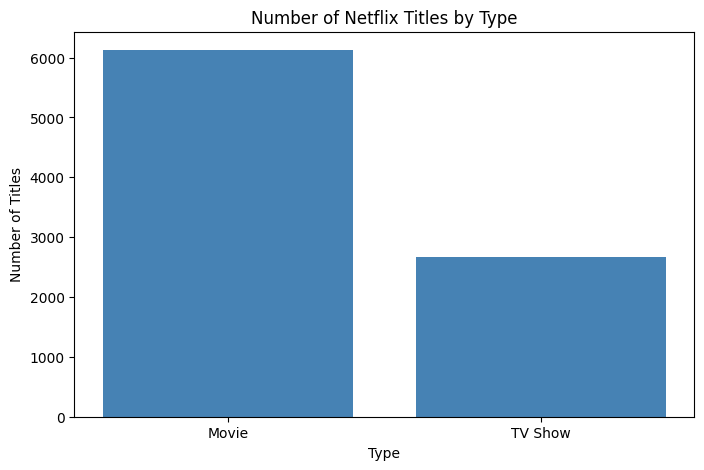

In [18]:
# 4.1 - bar chart: titles by type
type_counts = df["type"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(type_counts.index, type_counts.values, color="steelblue")

plt.title("Number of Netflix Titles by Type")
plt.xlabel("Type")
plt.ylabel("Number of Titles")

plt.show()

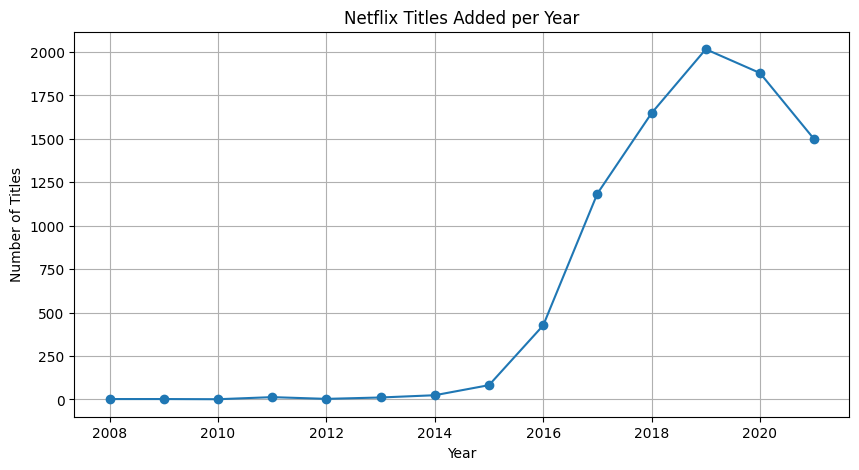

In [19]:
# 4.2 - line chart: titles added per year
titles_per_year = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(
    titles_per_year.index,
    titles_per_year.values,
    marker="o"
)

plt.title("Netflix Titles Added per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True)

plt.show()

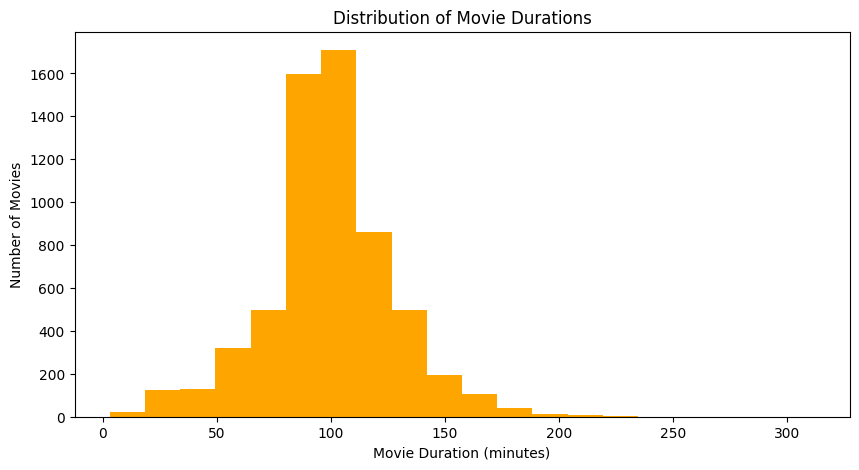

In [20]:
# 4.3 - histogram: movie durations
movies = df[df["type"] == "Movie"]

plt.figure(figsize=(10, 5))
plt.hist(movies["duration_value"], bins=20, color="orange")

plt.title("Distribution of Movie Durations")
plt.xlabel("Movie Duration (minutes)")
plt.ylabel("Number of Movies")

plt.show()

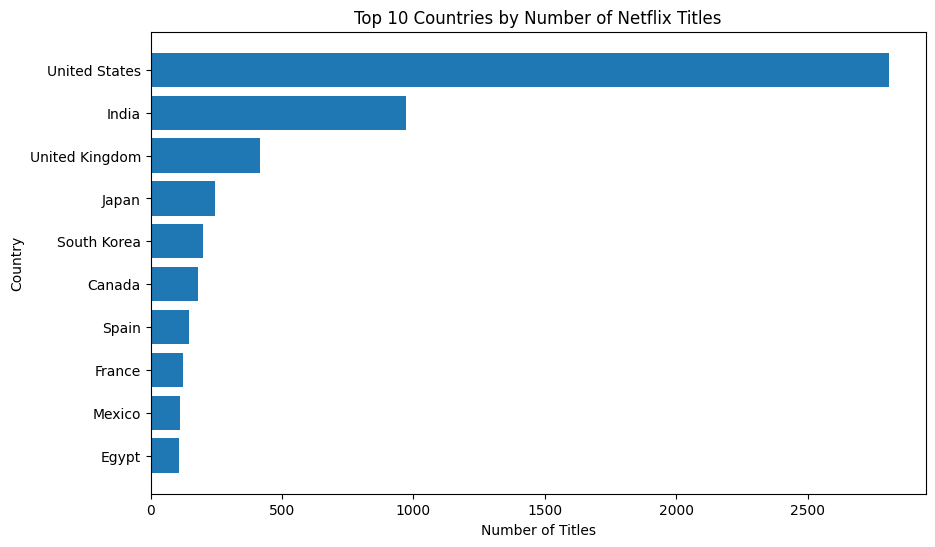

In [21]:
# 4.4 - horizontal bar chart: top 10 countries
top_countries = df[df["country"] != "Unknown"]["country"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_countries.index, top_countries.values)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.show()

## Part 5 - Functions

Time to combine your own functions, conditionals and pandas.

**5.1** Write a function `classify_duration(minutes)` that takes one number and returns one of three strings:

- `"Short"` if the movie is shorter than 60 minutes
- `"Standard"` from 60 up to and including 120 minutes
- `"Long"` for anything above 120 minutes

Mind the boundaries: exactly 60 and exactly 120 are both `"Standard"`.

Then, in the same cell:

1. Make a movies-only DataFrame with `.copy()`. Without the copy, pandas complains with a `SettingWithCopyWarning` when you add a column to a selection.
2. Apply your function to `duration_value` to create a new column `length_category`.
3. Show how many movies fall into each of the three categories, and show `title`, `duration_value` and `length_category` for the first 5 rows as a spot check.

Hint: `.apply()` runs your own function on every value of a column.

**5.2** Write a function `country_report(data, country_name)` with exactly those two parameters, that prints a report in this structure:

```
Report for <country>
  Total titles: XXX
  Movies: XXX
  TV Shows: XXX
  Oldest release year: XXXX
  Newest release year: XXXX
```

Inside the function, reuse the text-search trick from Q6 to select the country. Then pick three countries that interest you, put them in a list, and call your function for each of them with a for loop. Three copy-pasted calls without a loop is not what is asked.


In [22]:
# 5.1 - classify_duration function + length_category column + counts + spot check
def classify_duration(minutes):
    if minutes < 60:
        return "Short"
    elif minutes <= 120:
        return "Standard"
    else:
        return "Long"


movies = df[df["type"] == "Movie"].copy()

movies["length_category"] = movies["duration_value"].apply(classify_duration)

print(movies["length_category"].value_counts())

print(movies[["title", "duration_value", "length_category"]].head(5))

length_category
Standard    4527
Long        1142
Short        457
Name: count, dtype: int64
                               title  duration_value length_category
0               Dick Johnson Is Dead              90        Standard
6   My Little Pony: A New Generation              91        Standard
7                            Sankofa             125            Long
9                       The Starling             104        Standard
12                      Je Suis Karl             127            Long


In [23]:
# 5.2 - country_report function + loop over three countries
def country_report(data, country_name):
    country_data = data[
        data["country"].str.contains(country_name, case=False, na=False)
    ]

    total_titles = len(country_data)
    movies = (country_data["type"] == "Movie").sum()
    tv_shows = (country_data["type"] == "TV Show").sum()
    oldest_year = country_data["release_year"].min()
    newest_year = country_data["release_year"].max()

    print(f"Report for {country_name}")
    print(f"  Total titles: {total_titles}")
    print(f"  Movies: {movies}")
    print(f"  TV Shows: {tv_shows}")
    print(f"  Oldest release year: {oldest_year}")
    print(f"  Newest release year: {newest_year}")


countries = ["United States", "India", "Netherlands"]

for country in countries:
    country_report(df, country)

Report for United States
  Total titles: 3681
  Movies: 2749
  TV Shows: 932
  Oldest release year: 1942
  Newest release year: 2021
Report for India
  Total titles: 1046
  Movies: 962
  TV Shows: 84
  Oldest release year: 1959
  Newest release year: 2021
Report for Netherlands
  Total titles: 50
  Movies: 42
  TV Shows: 8
  Oldest release year: 2002
  Newest release year: 2021


## Part 6 - Insights

The point of all this work is to go from data to information to insight. Parts 1 to 5 gave you the information. Now write five insights in the text cell below.

Rules for each insight:

- Exactly two sentences.
- The first sentence states what the data shows and contains at least one number from your own results above.
- The second sentence says why that could matter, for Netflix, for a competitor, for a viewer, for anyone. This is your interpretation; there is no single right answer, but there must be an answer.
- The five insights must come from different parts of your analysis. Five variations on the movie versus TV show split is one insight, written five times.

An observation without a number is an opinion, and a number without a "so what" is trivia.

Example of the expected level (do not reuse it): "Almost 70 percent of the catalogue consists of movies, yet the platform is best known for its series. This suggests the brand image is driven by a small share of the content, which raises the question of what all those movies are for."


**Insight 1:** Movies make up to around 70% of the Netflix catalogue, with 6,126 movies compared to only 2,664 TV shows. This shows that the catalogue is much more focused on movies than TV shows.

**Insight 2:** Netflix added the most titles in 2019, with 2,016 titles added that year.

**Insight 3:** The average lenght of the movies in the catalogue is around 99 minutes which shows that most of the movies in the catalogue are with a length between 60 and 120 minutes

**Insight 4:** The United States is the production country for 2,809 titles, which is much higher than India with 972 titles. This shows that the Netflix catalogue has a stronger connection with US-produced movies compared to other countries.

**Insight 5:** TV-MA is the most common rating in the whole catalogue, with 3,205 titles. This shows that mature-rated content makes up a significant part of the Netflix catalogue.


## Bonus - Genres (optional)

For when the six parts are done and you want more. The column `listed_in` contains the genres of each title, again separated by commas, and again one cell can hold several genres. Produce two things:

1. The 10 most common genres with their counts, where every genre is counted on its own even when it shares a cell with others. "Dramas, Comedies" is two genres, not one category.
2. A horizontal bar chart of that top 10, following the same rules as the Part 4 charts, biggest genre on top.

Two possible routes, pick one:

- The loop route: loop over `df["listed_in"]`, split each string on `", "`, and count every genre in a dictionary.
- The pandas route: chain `.str.split(", ")` with `.explode()` and `.value_counts()`. Shorter, but you have to figure out what `.explode()` does.


In [24]:
# Bonus (optional) - top 10 genres + horizontal bar chart


---
## Before you hand it in

1. Your name and student number are at the top.
2. Runtime > Restart session and run all. No errors, all charts visible.
3. Every output that had a prescribed structure follows it.
4. All text answers (1.4 and Part 6) are written in your own words.
5. The file is named `DS_FinalProject_LastName_StudentNumber.ipynb`.
